# ERA5 vs Observed Temperature — Comparison & Analysis

This notebook mirrors the precipitation comparison notebook but focuses on **2-metre air temperature**.

Questions addressed:
1. **Why do ERA5 and IGEBU temperature values differ?**
2. **Time series overlays** — visual comparison per river
3. **Monthly climatology and per-calendar-month correlation**
4. **Per-river overall correlation** (Tmax and Tmin separately)
5. **Why the correlation differs between rivers** — station assignment effect

---
**Data sources:**
- `data/outputs/master_dataset_monthly.csv` — contains `temp_max_observed` / `temp_min_observed` (IGEBU) and `era5_t2m_max` / `era5_t2m_min` / `era5_t2m_mean` (ERA5 reanalysis)
- Temperature sources per river come from 5 IGEBU climate stations (see `temp_source` column)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

ROOT = Path("../../")
df_all = pd.read_csv(ROOT / "data/outputs/master_dataset_monthly.csv", parse_dates=["date"])

# Keep rows where both Tmax columns exist (primary comparison)
df = df_all.dropna(subset=["temp_max_observed", "era5_t2m_max"]).copy()
df["month"] = df["date"].dt.month

# Tmin subset (fewer rows because some stations only record Tmax)
df_min = df_all.dropna(subset=["temp_min_observed", "era5_t2m_min"]).copy()
df_min["month"] = df_min["date"].dt.month

print(f"Rows with both Tmax columns: {len(df)}")
print(f"Rows with both Tmin columns: {len(df_min)}")
print(f"Rivers present: {sorted(df['river'].unique())}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Temp sources: {sorted(df['temp_source'].dropna().unique())}")
print()
print(df[["temp_max_observed", "era5_t2m_max", "temp_min_observed", "era5_t2m_min"]].describe().round(2))

Rows with both Tmax columns: 3730
Rows with both Tmin columns: 3412
Rivers present: ['Buzimba', 'Jiji', 'Kaburantwa', 'Mpanda', 'Mulembwe', 'Mutimbuzi', 'Nyakagunda', 'Nyamagana', 'Nyengwe', 'Rusizi']
Date range: 1981-01-01 → 2024-12-01
Temp sources: ['BUJUMBURA (Aeroport)', 'MPARAMBO', 'MPOTA (Tora)', 'NYANZA LAC (IRAT)', 'RWEGURA']

       temp_max_observed  era5_t2m_max  temp_min_observed  era5_t2m_min
count            3730.00       3730.00            3274.00       3730.00
mean               27.36         28.18              15.37         16.51
std                 4.35          2.85               4.22          2.24
min                12.12         23.09               6.23         10.25
25%                22.07         25.75              11.10         14.93
50%                29.30         27.31              17.07         16.41
75%                30.69         30.67              19.10         17.85
max                35.05         36.66              30.30         22.69


---
## 1. Why do ERA5 and IGEBU temperature values differ?

| Factor | IGEBU (observed) | ERA5 (reanalysis) |
|---|---|---|
| **Measurement type** | Thermometer at a specific site | Model output — assimilates satellite, radiosonde, surface data |
| **Spatial resolution** | Single point | 0.25° grid cell (~28 × 28 km) |
| **What it represents** | Temperature at gauge elevation | Spatial average at 2 m above the grid-cell surface |
| **Elevation effect** | Captures local altitude (e.g. Rwegura at ~2,000 m) | Smoothed over coarse terrain — misses steep lapse rates |
| **Tmax / Tmin definition** | Daily station extremes aggregated to monthly | Monthly maximum / minimum of hourly model output |

In northern Burundi, altitude varies dramatically within a single ERA5 cell. Stations at high elevation (e.g. Rwegura, ~2,000 m) will be systematically colder than their ERA5 grid point, which averages over lower surrounding terrain.

---
## 2. Distances between ERA5 grid points and IGEBU temperature stations

             Station Station coords    ERA5 grid  distance_km
   Nyanza Lac (IRAT)   -4.32, 29.62 -4.25, 29.50        15.42
            Mparambo   -2.83, 29.08 -2.75, 29.00        12.57
Bujumbura (Aéroport)   -3.32, 29.32 -3.25, 29.25        11.00
             Rwegura   -2.92, 29.52 -3.00, 29.50         9.17
        Mpota (Tora)   -3.73, 29.57 -3.75, 29.50         8.08

Mean distance: 11.2 km


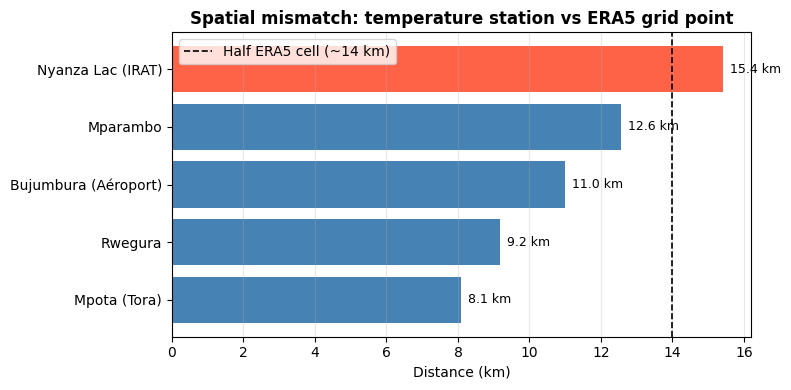

In [2]:
# Temperature station coordinates and their ERA5 grid points
temp_stations = [
    {"Station": "Nyanza Lac (IRAT)",     "st_lat": -4.32, "st_lon": 29.62, "era5_lat": -4.25, "era5_lon": 29.50},
    {"Station": "Mpota (Tora)",          "st_lat": -3.73, "st_lon": 29.57, "era5_lat": -3.75, "era5_lon": 29.50},
    {"Station": "Bujumbura (Aéroport)",  "st_lat": -3.32, "st_lon": 29.32, "era5_lat": -3.25, "era5_lon": 29.25},
    {"Station": "Mparambo",              "st_lat": -2.83, "st_lon": 29.08, "era5_lat": -2.75, "era5_lon": 29.00},
    {"Station": "Rwegura",               "st_lat": -2.92, "st_lon": 29.52, "era5_lat": -3.00, "era5_lon": 29.50},
]

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_stations = pd.DataFrame(temp_stations)
df_stations["distance_km"] = df_stations.apply(
    lambda r: haversine_km(r["st_lat"], r["st_lon"], r["era5_lat"], r["era5_lon"]), axis=1
).round(2)
df_stations["ERA5 grid"] = df_stations.apply(
    lambda r: f"{r['era5_lat']:.2f}, {r['era5_lon']:.2f}", axis=1
)
df_stations["Station coords"] = df_stations.apply(
    lambda r: f"{r['st_lat']:.2f}, {r['st_lon']:.2f}", axis=1
)

print(df_stations[["Station", "Station coords", "ERA5 grid", "distance_km"]]
      .sort_values("distance_km", ascending=False)
      .to_string(index=False))
print(f"\nMean distance: {df_stations['distance_km'].mean():.1f} km")

# Bar chart
df_plot = df_stations.sort_values("distance_km", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if d > 15 else "steelblue" for d in df_plot["distance_km"]]
bars = ax.barh(df_plot["Station"], df_plot["distance_km"], color=colors)
ax.axvline(14.0, color="black", linestyle="--", linewidth=1.2, label="Half ERA5 cell (~14 km)")
ax.set_xlabel("Distance (km)")
ax.set_title("Spatial mismatch: temperature station vs ERA5 grid point", fontweight="bold")
ax.legend()
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, df_plot["distance_km"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} km", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Visual comparison: Tmax and Tmin time series per river

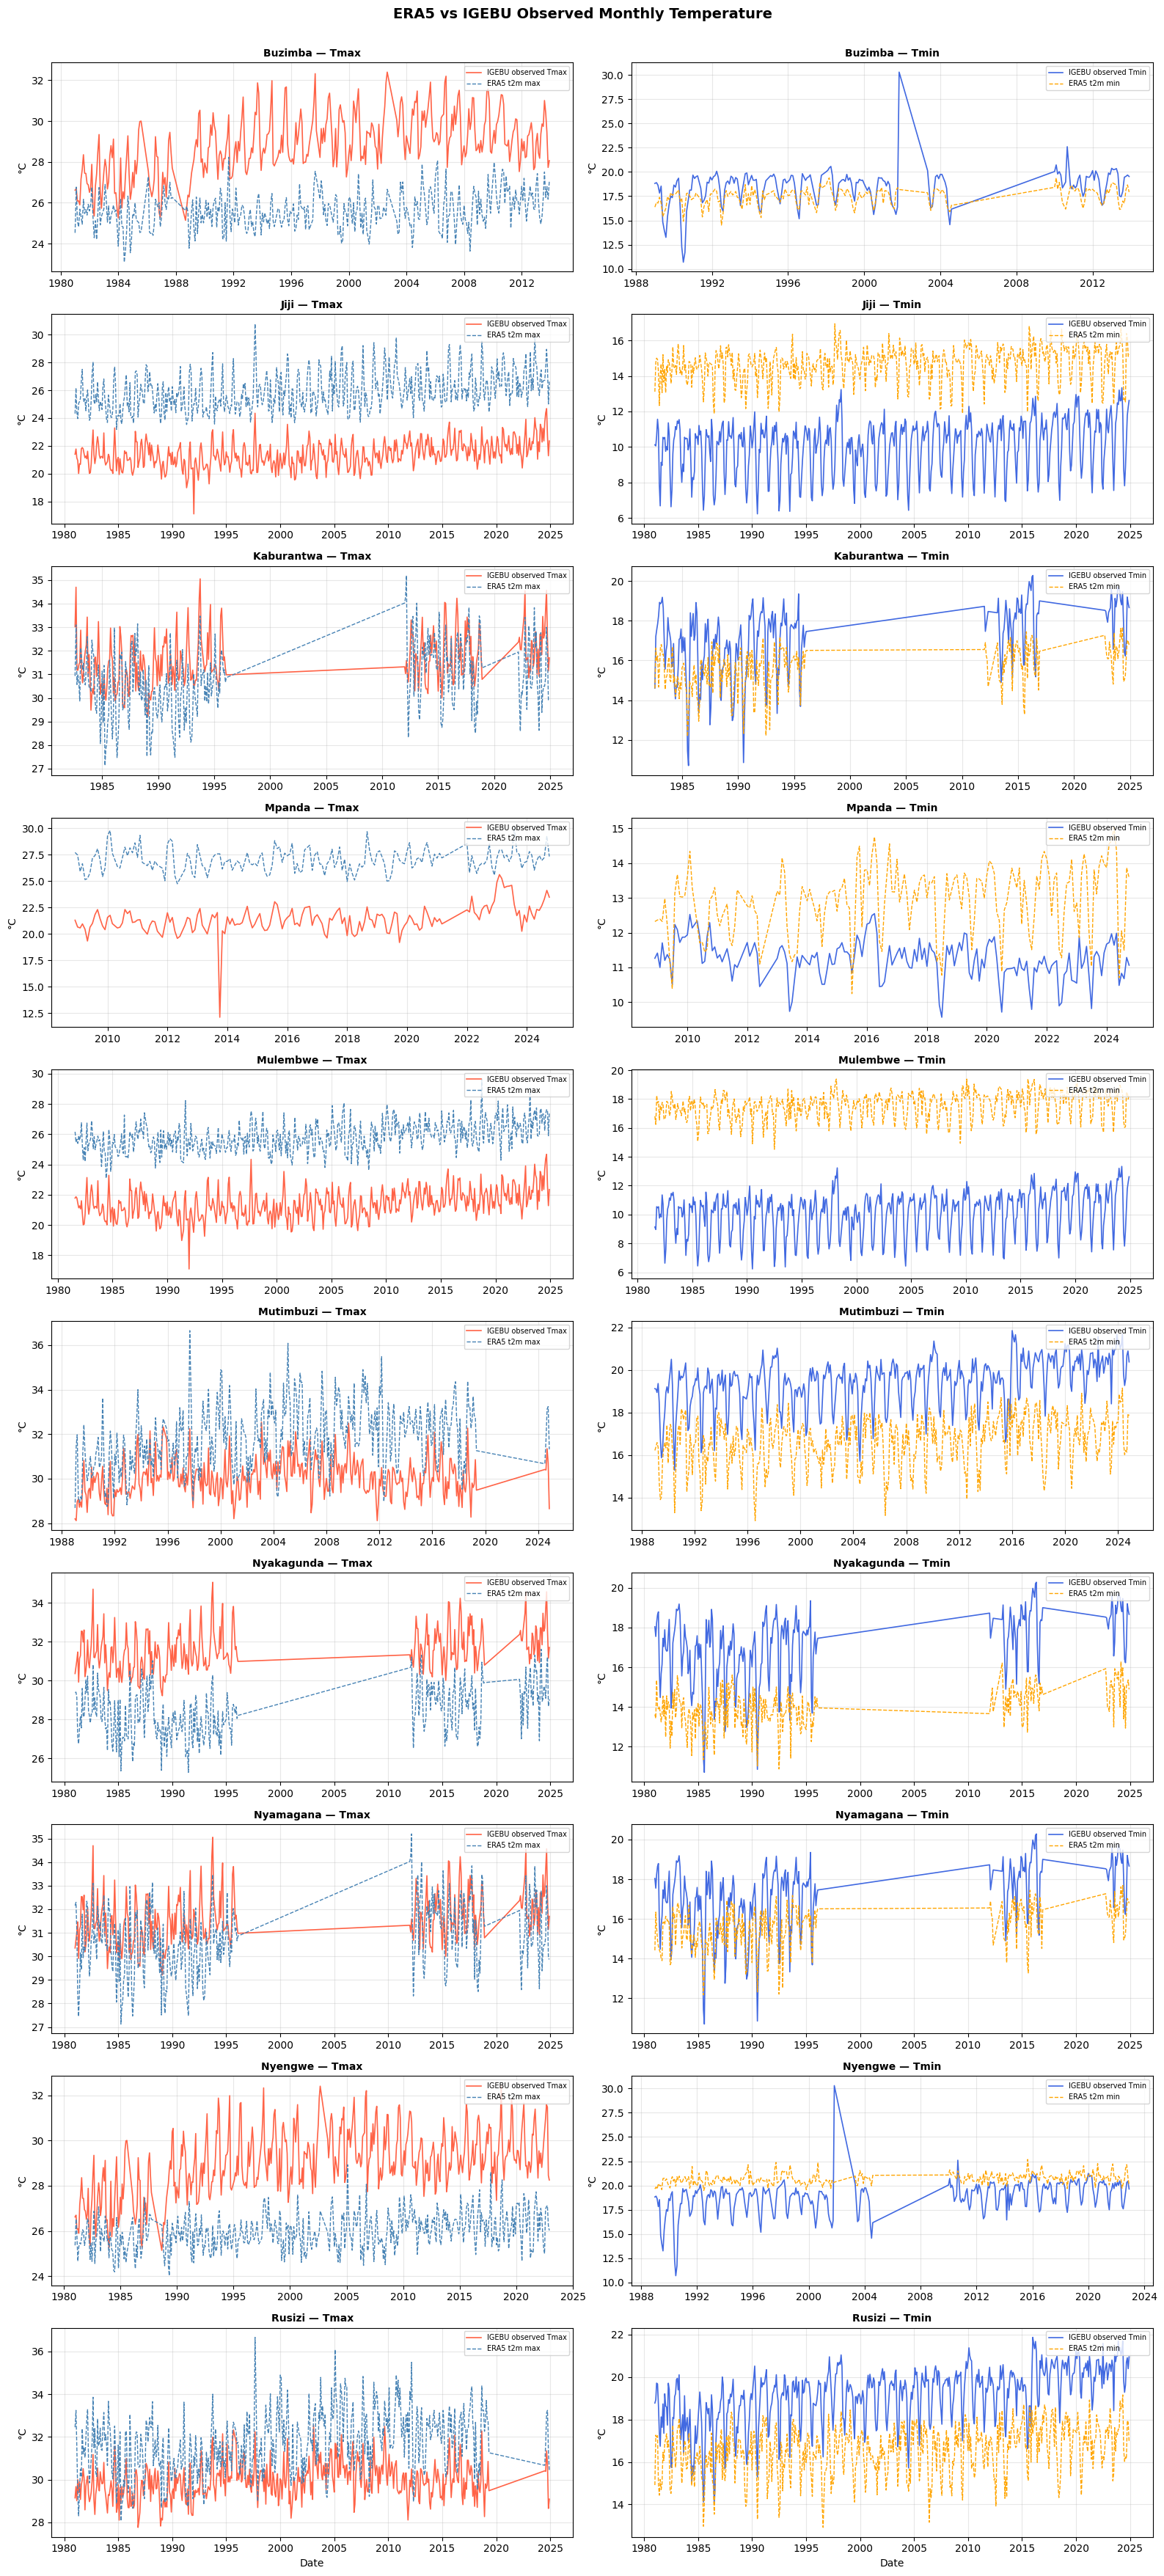

In [3]:
rivers = sorted(df["river"].unique())
n = len(rivers)
fig, axes = plt.subplots(n, 2, figsize=(16, 3.5 * n), sharex=False)

for i, river in enumerate(rivers):
    sub_max = df[df["river"] == river].sort_values("date")
    sub_min = df_min[df_min["river"] == river].sort_values("date")

    # Tmax
    ax = axes[i, 0]
    ax.plot(sub_max["date"], sub_max["temp_max_observed"], color="tomato", linewidth=1.2, label="IGEBU observed Tmax")
    ax.plot(sub_max["date"], sub_max["era5_t2m_max"], color="steelblue", linewidth=1.0, linestyle="--", label="ERA5 t2m max")
    ax.set_title(f"{river} — Tmax", fontsize=10, fontweight="bold")
    ax.set_ylabel("°C")
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(alpha=0.3)

    # Tmin
    ax = axes[i, 1]
    if len(sub_min) > 0:
        ax.plot(sub_min["date"], sub_min["temp_min_observed"], color="royalblue", linewidth=1.2, label="IGEBU observed Tmin")
        ax.plot(sub_min["date"], sub_min["era5_t2m_min"], color="orange", linewidth=1.0, linestyle="--", label="ERA5 t2m min")
        ax.legend(loc="upper right", fontsize=7)
    else:
        ax.text(0.5, 0.5, "No Tmin data", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"{river} — Tmin", fontsize=10, fontweight="bold")
    ax.set_ylabel("°C")
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
fig.suptitle("ERA5 vs IGEBU Observed Monthly Temperature", fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()

---
## 4. Monthly climatology and per-calendar-month correlation

Does ERA5 capture the seasonal temperature cycle even if the absolute values differ?

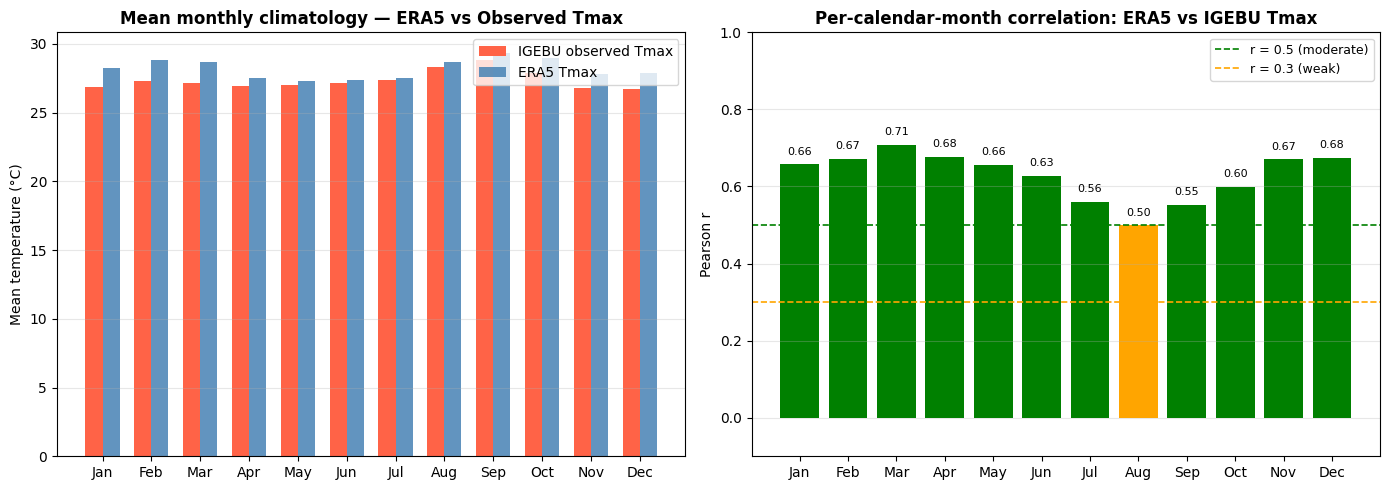

Per-calendar-month correlation (ERA5 vs IGEBU Tmax):
  Jan: r=+0.658  p=0.000*  n=306
  Feb: r=+0.671  p=0.000*  n=315
  Mar: r=+0.709  p=0.000*  n=313
  Apr: r=+0.677  p=0.000*  n=314
  May: r=+0.656  p=0.000*  n=314
  Jun: r=+0.628  p=0.000*  n=309
  Jul: r=+0.561  p=0.000*  n=315
  Aug: r=+0.500  p=0.000*  n=315
  Sep: r=+0.552  p=0.000*  n=310
  Oct: r=+0.599  p=0.000*  n=309
  Nov: r=+0.671  p=0.000*  n=304
  Dec: r=+0.675  p=0.000*  n=306
  * = statistically significant at p < 0.05



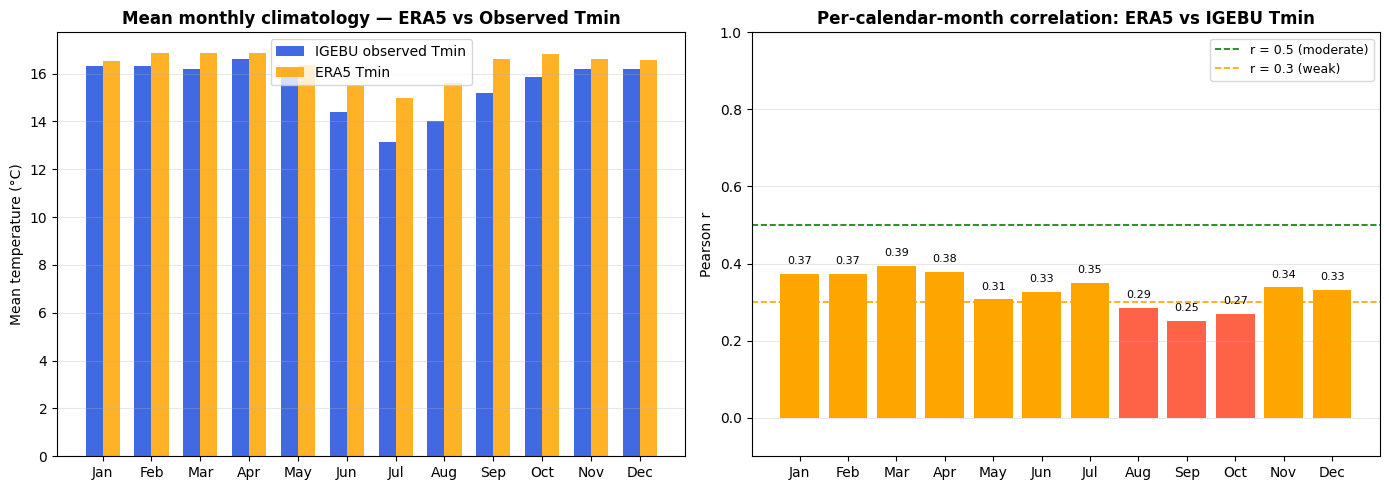

Per-calendar-month correlation (ERA5 vs IGEBU Tmin):
  Jan: r=+0.372  p=0.000*  n=285
  Feb: r=+0.373  p=0.000*  n=290
  Mar: r=+0.394  p=0.000*  n=290
  Apr: r=+0.378  p=0.000*  n=284
  May: r=+0.307  p=0.000*  n=288
  Jun: r=+0.327  p=0.000*  n=282
  Jul: r=+0.350  p=0.000*  n=286
  Aug: r=+0.285  p=0.000*  n=288
  Sep: r=+0.252  p=0.000*  n=278
  Oct: r=+0.269  p=0.000*  n=282
  Nov: r=+0.339  p=0.000*  n=280
  Dec: r=+0.333  p=0.000*  n=279
  * = statistically significant at p < 0.05



In [4]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for label, obs_col, era5_col, dff in [
    ("Tmax", "temp_max_observed", "era5_t2m_max", df),
    ("Tmin", "temp_min_observed", "era5_t2m_min", df_min),
]:
    monthly_clim = dff.groupby("month")[[obs_col, era5_col]].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    x = np.arange(12)
    w = 0.35
    ax.bar(x - w/2, monthly_clim[obs_col], w, label=f"IGEBU observed {label}", color="tomato" if label == "Tmax" else "royalblue")
    ax.bar(x + w/2, monthly_clim[era5_col], w, label=f"ERA5 {label}", color="steelblue" if label == "Tmax" else "orange", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(month_names)
    ax.set_ylabel("Mean temperature (°C)")
    ax.set_title(f"Mean monthly climatology — ERA5 vs Observed {label}", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    monthly_r = []
    for m in range(1, 13):
        sub = dff[dff["month"] == m]
        if len(sub) >= 5:
            r_val, p_val = stats.pearsonr(sub[obs_col], sub[era5_col])
        else:
            r_val, p_val = np.nan, np.nan
        monthly_r.append({"month": m, "r": r_val, "p": p_val, "n": len(sub)})
    df_mr = pd.DataFrame(monthly_r)

    ax = axes[1]
    colors = ["green" if r >= 0.5 else ("orange" if r >= 0.3 else "tomato") for r in df_mr["r"]]
    bars = ax.bar(df_mr["month"] - 1, df_mr["r"], color=colors)
    ax.axhline(0.5, color="green", linestyle="--", linewidth=1.2, label="r = 0.5 (moderate)")
    ax.axhline(0.3, color="orange", linestyle="--", linewidth=1.2, label="r = 0.3 (weak)")
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_names)
    ax.set_ylabel("Pearson r")
    ax.set_ylim(-0.1, 1.0)
    ax.set_title(f"Per-calendar-month correlation: ERA5 vs IGEBU {label}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar, row in zip(bars, df_mr.itertuples()):
        if not np.isnan(row.r):
            ax.text(bar.get_x() + bar.get_width()/2, row.r + 0.02,
                    f"{row.r:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"Per-calendar-month correlation (ERA5 vs IGEBU {label}):")
    for row in df_mr.itertuples():
        sig = "*" if row.p < 0.05 else " "
        print(f"  {month_names[row.month-1]:>3}: r={row.r:+.3f}  p={row.p:.3f}{sig}  n={row.n}")
    print("  * = statistically significant at p < 0.05\n")

---
## 5. Per-river overall correlation

Overall Pearson r per river (ERA5 vs IGEBU Tmax):
River                     r        p      n   bias (°C)  temp_source
------------------------------------------------------------------------
Buzimba              +0.337  0.0000    364       -3.21  NYANZA LAC (IRAT)
Jiji                 +0.766  0.0000    517       +4.54  MPOTA (Tora)
Kaburantwa           +0.492  0.0000    276       -0.87  MPARAMBO
Mpanda               +0.422  0.0000    175       +5.58  RWEGURA
Mulembwe             +0.689  0.0000    510       +4.45  MPOTA (Tora)
Mutimbuzi            +0.507  0.0000    365       +1.81  BUJUMBURA (Aeroport)
Nyakagunda           +0.407  0.0000    295       -3.15  MPARAMBO
Nyamagana            +0.477  0.0000    295       -0.87  MPARAMBO
Nyengwe              +0.412  0.0000    471       -3.03  NYANZA LAC (IRAT)
Rusizi               +0.525  0.0000    462       +1.78  BUJUMBURA (Aeroport)



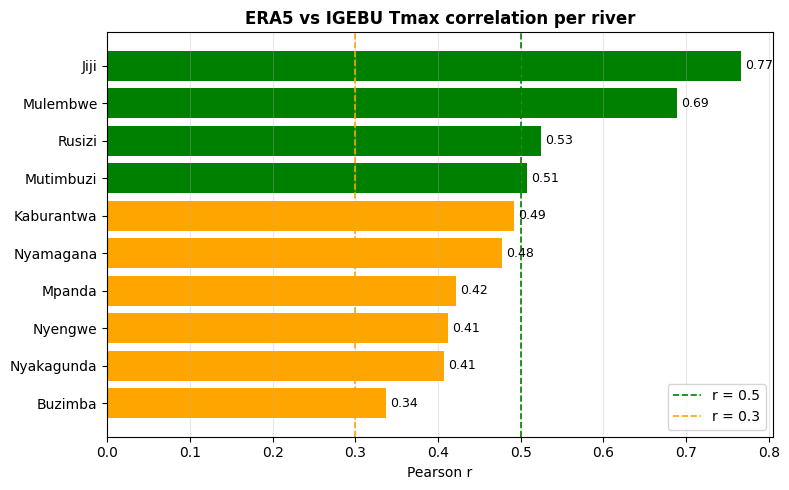

Overall Pearson r per river (ERA5 vs IGEBU Tmin):
River                     r        p      n   bias (°C)  temp_source
------------------------------------------------------------------------
Buzimba              +0.613  0.0000    204       -1.00  NYANZA LAC (IRAT)
Jiji                 +0.676  0.0000    516       +4.57  MPOTA (Tora)
Kaburantwa           +0.657  0.0000    236       -1.49  MPARAMBO
Mpanda               +0.582  0.0000    177       +1.68  RWEGURA
Mulembwe             +0.790  0.0000    509       +7.46  MPOTA (Tora)
Mutimbuzi            +0.703  0.0000    426       -2.82  BUJUMBURA (Aeroport)
Nyakagunda           +0.562  0.0000    255       -3.11  MPARAMBO
Nyamagana            +0.648  0.0000    255       -1.52  MPARAMBO
Nyengwe              +0.195  0.0005    311       +1.86  NYANZA LAC (IRAT)
Rusizi               +0.683  0.0000    523       -2.62  BUJUMBURA (Aeroport)



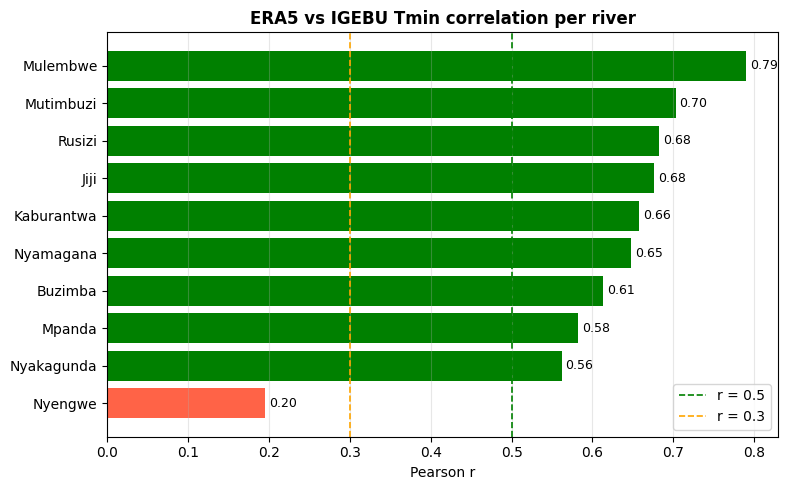

In [5]:
for label, obs_col, era5_col, dff in [
    ("Tmax", "temp_max_observed", "era5_t2m_max", df),
    ("Tmin", "temp_min_observed", "era5_t2m_min", df_min),
]:
    print(f"Overall Pearson r per river (ERA5 vs IGEBU {label}):")
    print(f"{'River':<20} {'r':>6}  {'p':>7}  {'n':>5}  {'bias (°C)':>10}  {'temp_source'}")
    print("-" * 72)
    per_river_results = []
    for river in sorted(dff["river"].unique()):
        sub = dff[dff["river"] == river]
        if len(sub) >= 5:
            r_val, p_val = stats.pearsonr(sub[obs_col], sub[era5_col])
            bias = (sub[era5_col] - sub[obs_col]).mean()
            src = sub["temp_source"].dropna().iloc[0] if sub["temp_source"].notna().any() else "unknown"
            print(f"{river:<20} {r_val:+.3f}  {p_val:.4f}  {len(sub):>5}  {bias:>+10.2f}  {src}")
            per_river_results.append({"river": river, "r": r_val, "p": p_val, "n": len(sub), "bias": bias})
        else:
            print(f"{river:<20}  (insufficient data, n={len(sub)})")
    print()

    df_prr = pd.DataFrame(per_river_results).sort_values("r", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["green" if r >= 0.5 else ("orange" if r >= 0.3 else "tomato") for r in df_prr["r"]]
    bars = ax.barh(df_prr["river"], df_prr["r"], color=colors)
    ax.axvline(0.5, color="green", linestyle="--", linewidth=1.2, label="r = 0.5")
    ax.axvline(0.3, color="orange", linestyle="--", linewidth=1.2, label="r = 0.3")
    ax.set_xlabel("Pearson r")
    ax.set_title(f"ERA5 vs IGEBU {label} correlation per river", fontweight="bold")
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, df_prr["r"]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 6. Scatter plots: observed vs ERA5 temperature per river

Each point is one station-month. The dashed line is the 1:1 reference.

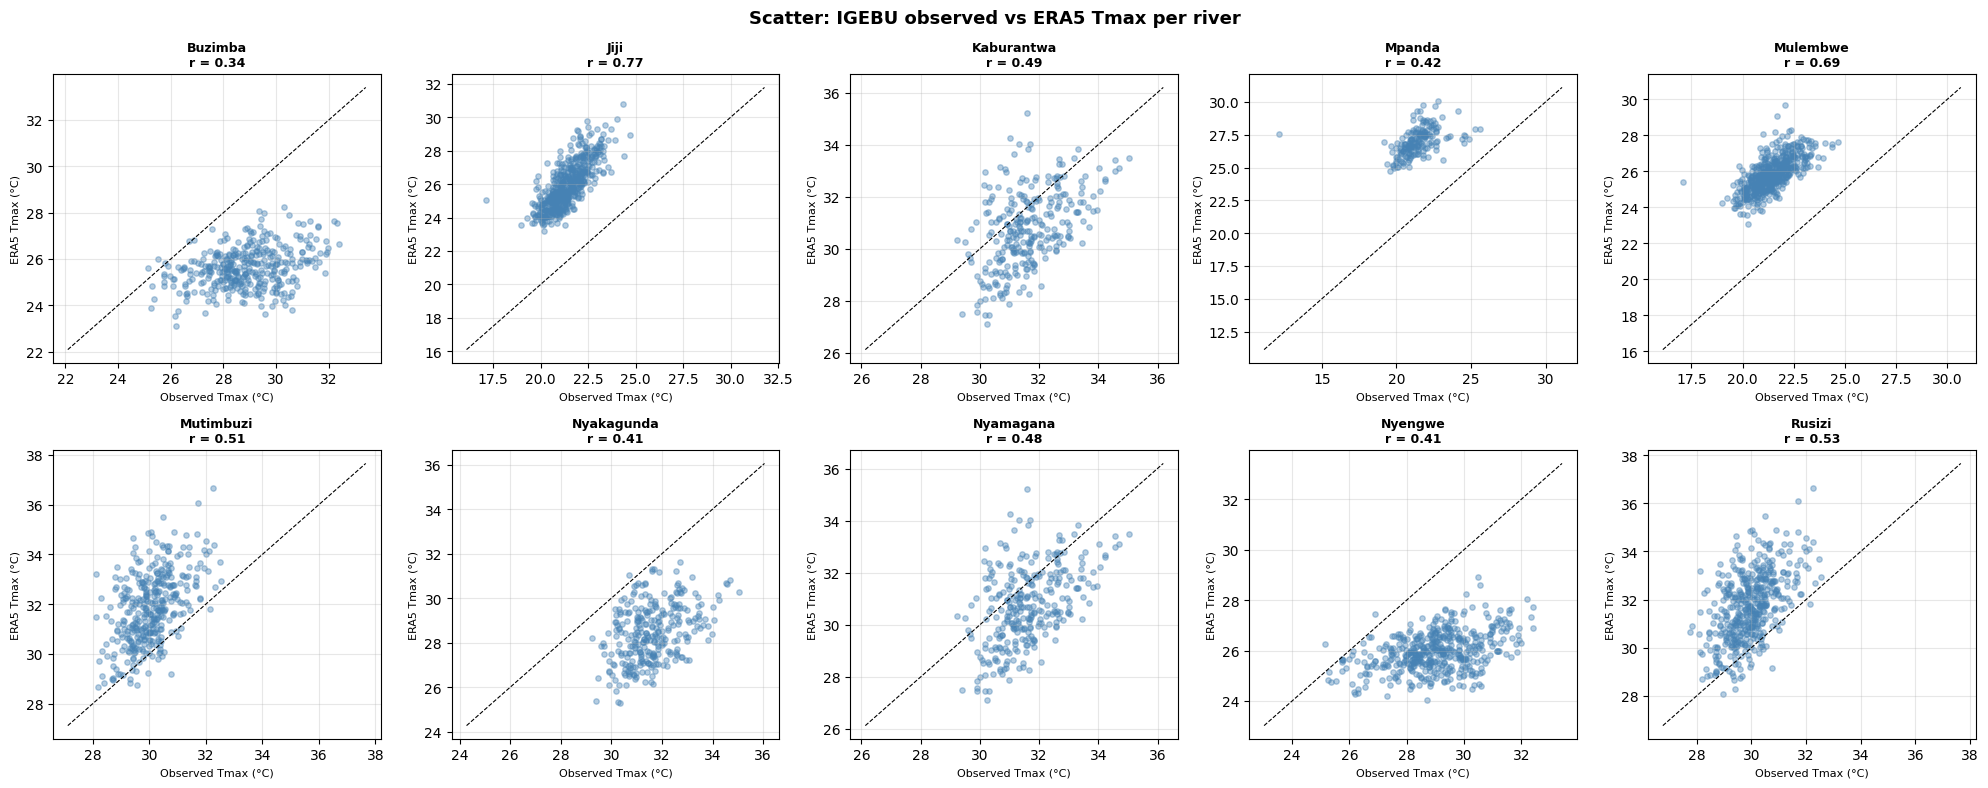

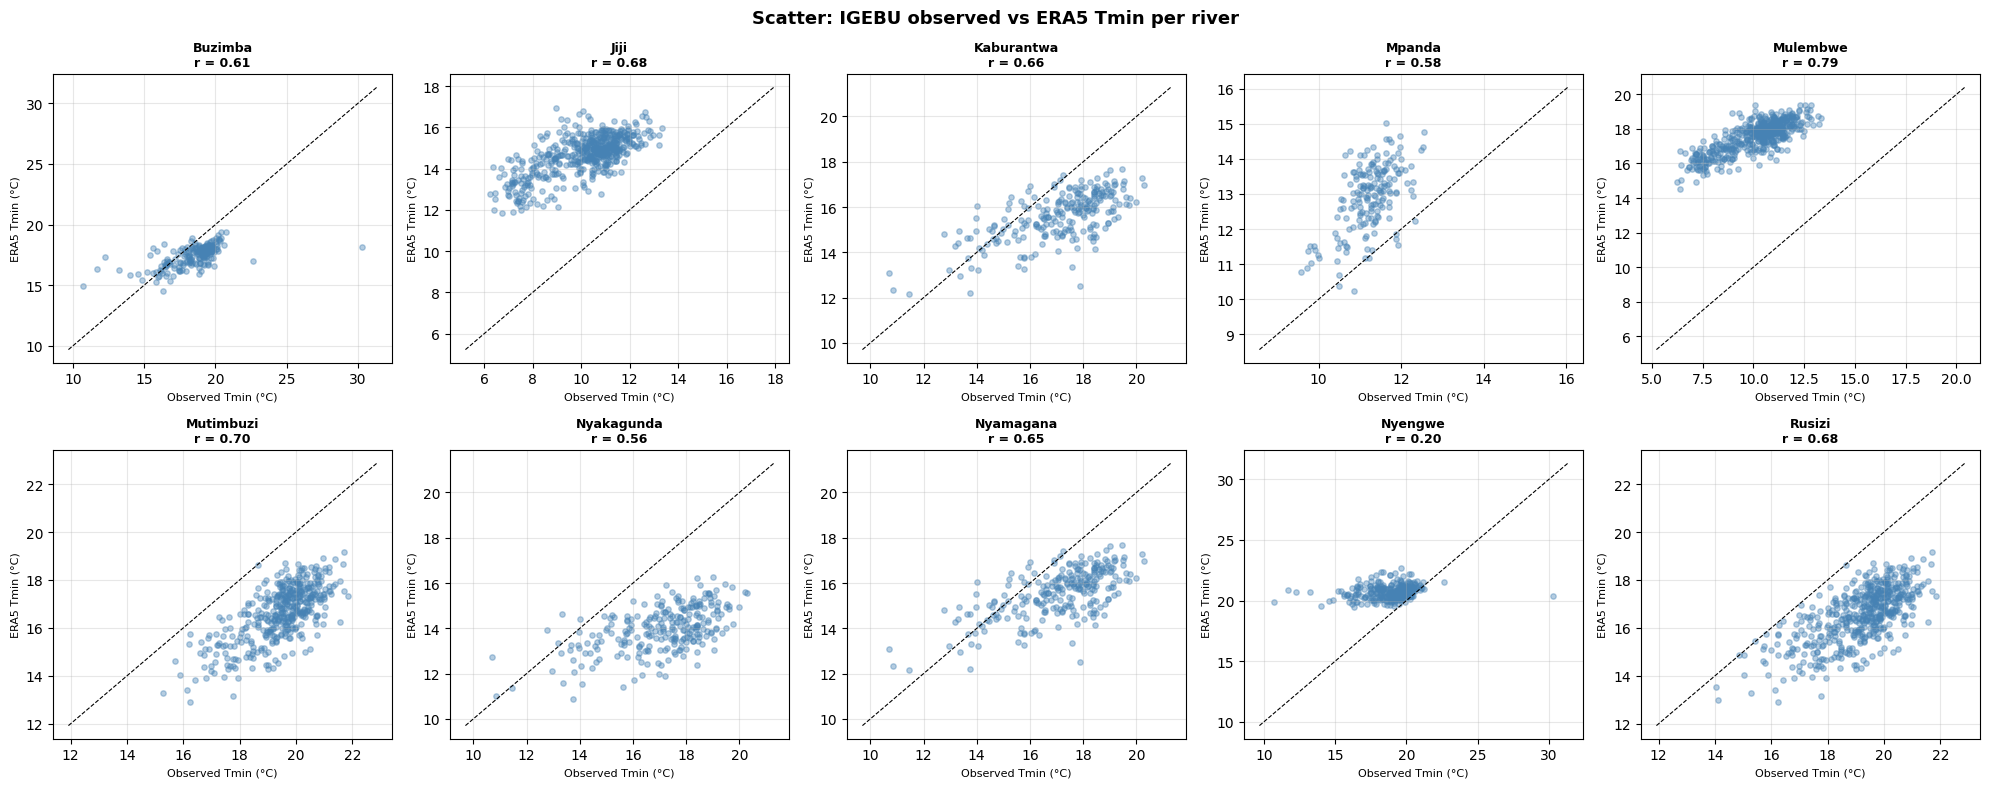

In [6]:
for label, obs_col, era5_col, dff in [
    ("Tmax", "temp_max_observed", "era5_t2m_max", df),
    ("Tmin", "temp_min_observed", "era5_t2m_min", df_min),
]:
    rivers = sorted(dff["river"].unique())
    ncols = 5
    nrows = int(np.ceil(len(rivers) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, river in zip(axes, rivers):
        sub = dff[dff["river"] == river]
        ax.scatter(sub[obs_col], sub[era5_col], alpha=0.4, s=15, color="steelblue")
        lims = [min(sub[obs_col].min(), sub[era5_col].min()) - 1,
                max(sub[obs_col].max(), sub[era5_col].max()) + 1]
        ax.plot(lims, lims, "k--", linewidth=0.8, label="1:1")
        if len(sub) >= 5:
            r_val, _ = stats.pearsonr(sub[obs_col], sub[era5_col])
            ax.set_title(f"{river}\nr = {r_val:.2f}", fontsize=9, fontweight="bold")
        else:
            ax.set_title(f"{river}\n(n<5)", fontsize=9)
        ax.set_xlabel(f"Observed {label} (°C)", fontsize=8)
        ax.set_ylabel(f"ERA5 {label} (°C)", fontsize=8)
        ax.grid(alpha=0.3)

    for ax in axes[len(rivers):]:
        ax.set_visible(False)

    fig.suptitle(f"Scatter: IGEBU observed vs ERA5 {label} per river", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 7. Why does the per-river correlation split by temperature station?

Like precipitation, each river's `temp_max_observed` / `temp_min_observed` comes from the nearest IGEBU climate station — **not** from a sensor at the river gauge itself. The ERA5 correlation therefore reflects how well ERA5 agrees with *that particular climate station*.

Key factor for temperature: **elevation**. ERA5 represents a ~28 km grid cell average, smoothing out the extreme topography of the Albertine Rift. Stations at high altitude (e.g. Rwegura, ~2,000 m) will show a systematic cold bias relative to ERA5, and potentially different correlation patterns than low-elevation stations near the lake shore (e.g. Bujumbura, ~780 m).

| River | Gauge station | Temp source station | Approx elevation |
|---|---|---|---|
| Buzimba | Buzimba (Gatete) | Nyanza Lac (IRAT) | ~790 m |
| Nyengwe | Nyengwe (Rimbo) | Nyanza Lac (IRAT) | ~790 m |
| Mulembwe | Mulembwe (Mutambara) | Mpota (Tora) | ~800 m |
| Jiji | Jiji (Ndago) | Mpota (Tora) | ~800 m |
| Mpanda | Mpanda (Gatura) | Rwegura | ~2,000 m |
| Mutimbuzi | Mutimbuzi (Pont Aéroport) | Bujumbura (Aéroport) | ~782 m |
| Rusizi | Rusizi (Gatumba) | Bujumbura (Aéroport) | ~782 m |
| Kaburantwa | Kaburantwa (Mission) | Mparambo | ~1,000 m |
| Nyamagana | Nyamagana (Murambi) | Mparambo | ~1,000 m |
| Nyakagunda | Nyakagunda (Musenyi) | Mparambo | ~1,000 m |

In [7]:
# Bias and correlation grouped by temperature source station
print("Tmax bias (ERA5 − observed) and correlation by temperature source station:")
print(f"{'Source station':<30} {'mean bias (°C)':>14}  {'median bias':>12}  {'r':>6}  {'n':>5}")
print("-" * 72)
for src in sorted(df["temp_source"].dropna().unique()):
    sub = df[df["temp_source"] == src].dropna(subset=["temp_max_observed", "era5_t2m_max"])
    if len(sub) < 5:
        continue
    bias = (sub["era5_t2m_max"] - sub["temp_max_observed"])
    r_val, _ = stats.pearsonr(sub["temp_max_observed"], sub["era5_t2m_max"])
    print(f"{src:<30} {bias.mean():>+14.2f}  {bias.median():>+12.2f}  {r_val:>+6.3f}  {len(sub):>5}")

print()
print("Tmin bias (ERA5 − observed) and correlation by temperature source station:")
print(f"{'Source station':<30} {'mean bias (°C)':>14}  {'median bias':>12}  {'r':>6}  {'n':>5}")
print("-" * 72)
for src in sorted(df_min["temp_source"].dropna().unique()):
    sub = df_min[df_min["temp_source"] == src].dropna(subset=["temp_min_observed", "era5_t2m_min"])
    if len(sub) < 5:
        continue
    bias = (sub["era5_t2m_min"] - sub["temp_min_observed"])
    r_val, _ = stats.pearsonr(sub["temp_min_observed"], sub["era5_t2m_min"])
    print(f"{src:<30} {bias.mean():>+14.2f}  {bias.median():>+12.2f}  {r_val:>+6.3f}  {len(sub):>5}")

Tmax bias (ERA5 − observed) and correlation by temperature source station:
Source station                 mean bias (°C)   median bias       r      n
------------------------------------------------------------------------
BUJUMBURA (Aeroport)                    +1.79         +1.70  +0.519    827
MPARAMBO                                -1.65         -1.66  +0.367    866
MPOTA (Tora)                            +4.50         +4.42  +0.723   1027
NYANZA LAC (IRAT)                       -3.11         -3.00  +0.380    835
RWEGURA                                 +5.58         +5.62  +0.422    175

Tmin bias (ERA5 − observed) and correlation by temperature source station:
Source station                 mean bias (°C)   median bias       r      n
------------------------------------------------------------------------
BUJUMBURA (Aeroport)                    -2.71         -2.71  +0.688    949
MPARAMBO                                -2.05         -2.05  +0.504    746
MPOTA (Tora)                